In [5]:
# Install YOLOv8 dan Roboflow
!pip install -q ultralytics roboflow

from ultralytics import YOLO

In [6]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jZQiypkEx8wEppU7GgpC")
project = rf.workspace("yolo-project-0sfck").project("helmet-detection-ligfk")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [7]:
import os

for root, dirs, files in os.walk(dataset.location):
    print(root)

/content/Helmet-Detection-3
/content/Helmet-Detection-3/valid
/content/Helmet-Detection-3/valid/labels
/content/Helmet-Detection-3/valid/images
/content/Helmet-Detection-3/test
/content/Helmet-Detection-3/test/labels
/content/Helmet-Detection-3/test/images
/content/Helmet-Detection-3/train
/content/Helmet-Detection-3/train/labels
/content/Helmet-Detection-3/train/images


In [10]:
model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device='cpu'
)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Helmet-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79b75674a810>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

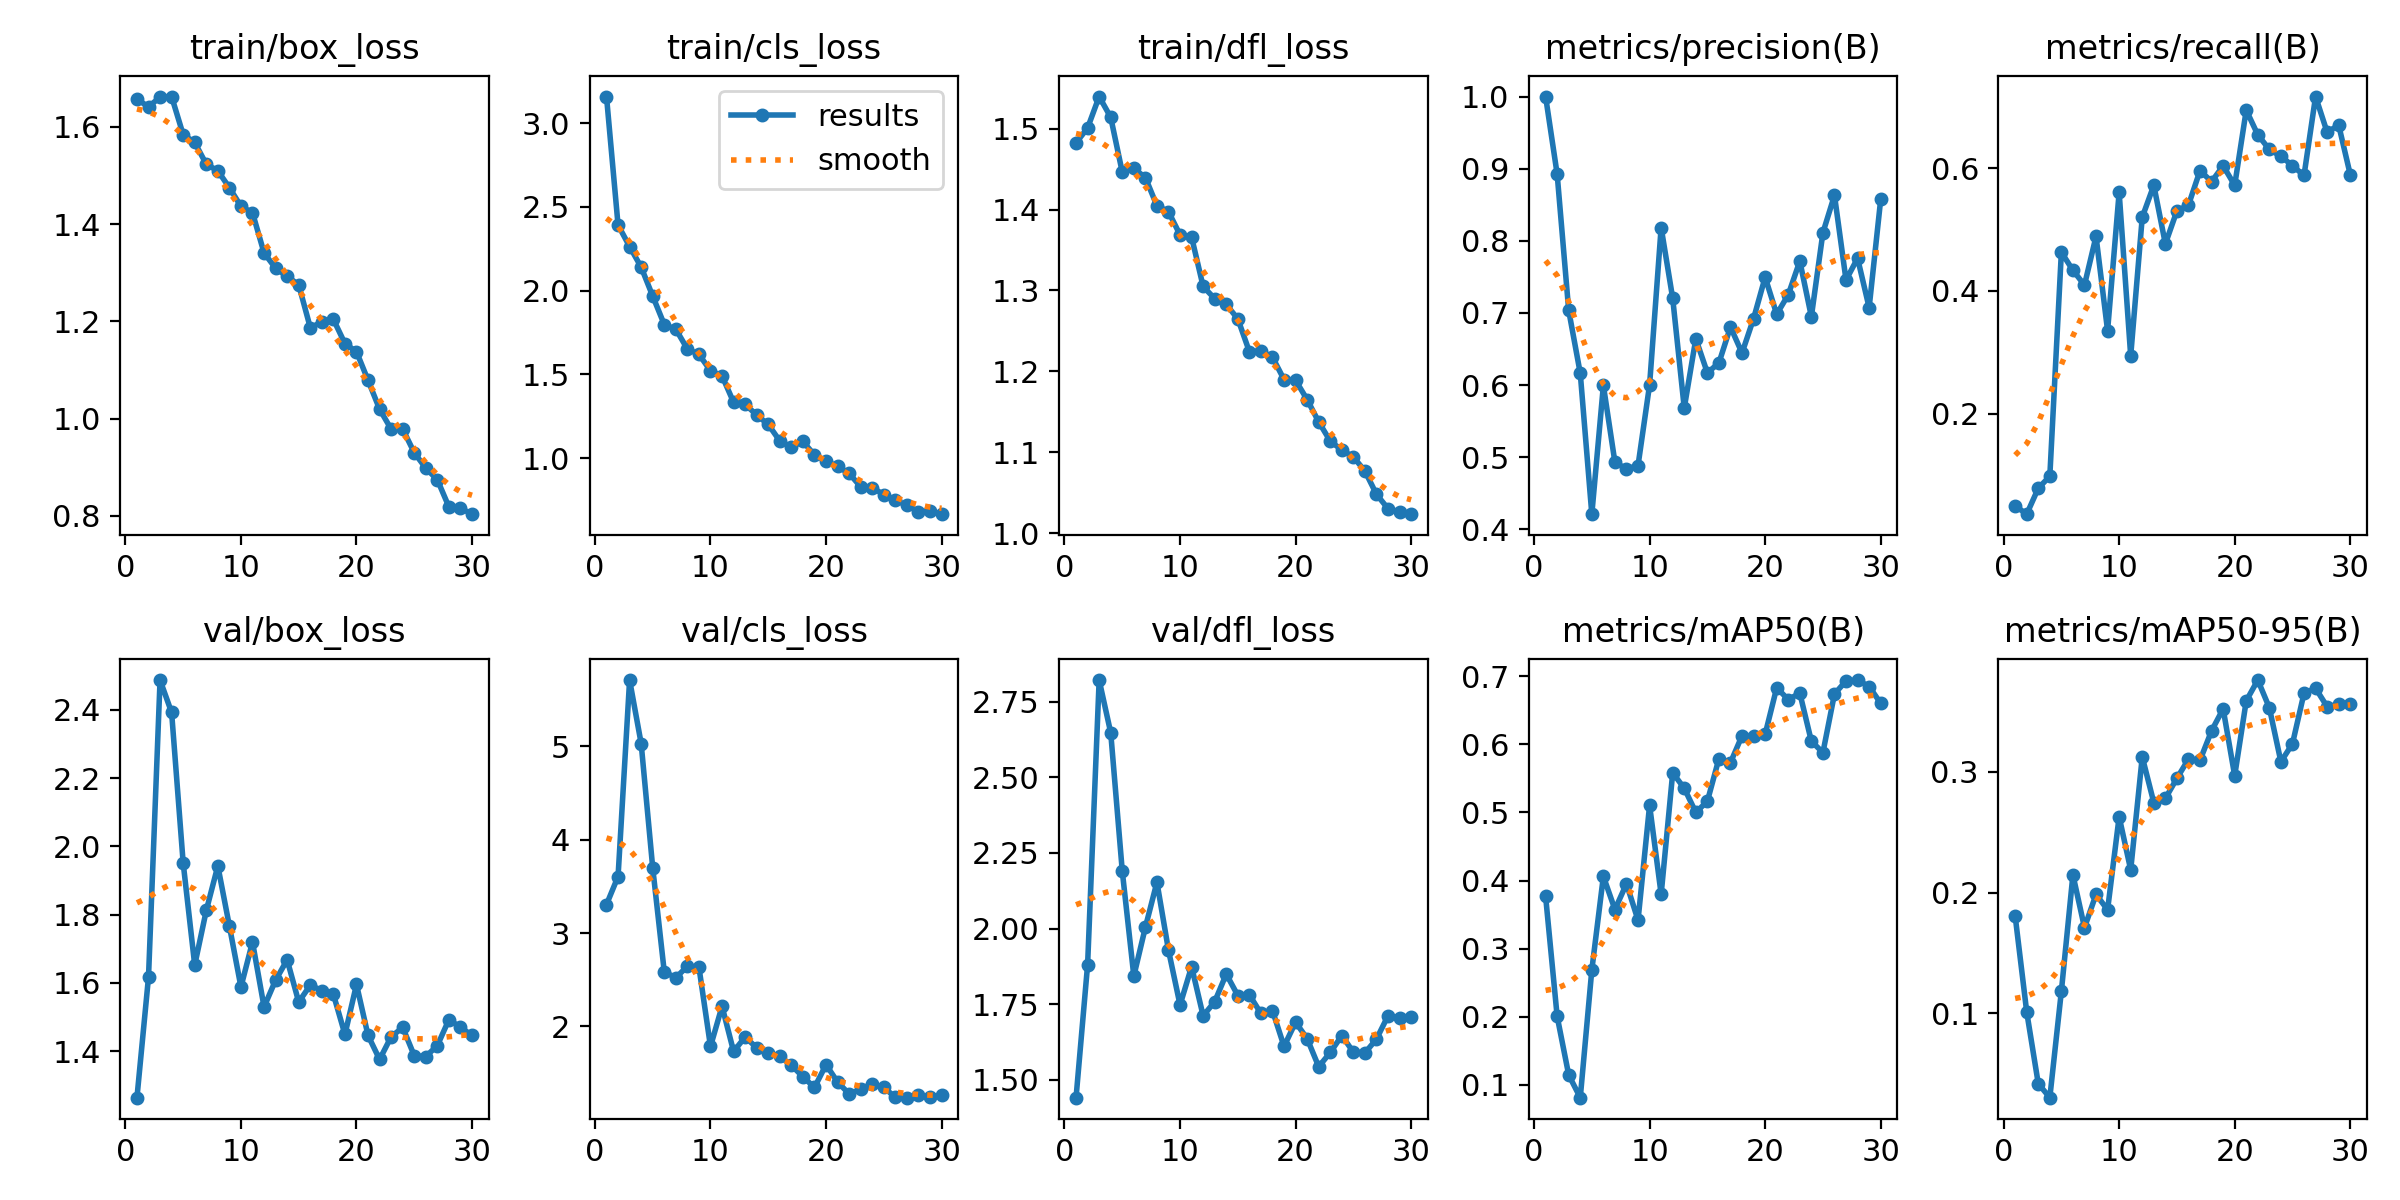

In [12]:
from IPython.display import Image, display

display(Image(filename="runs/detect/train-2/results.png"))

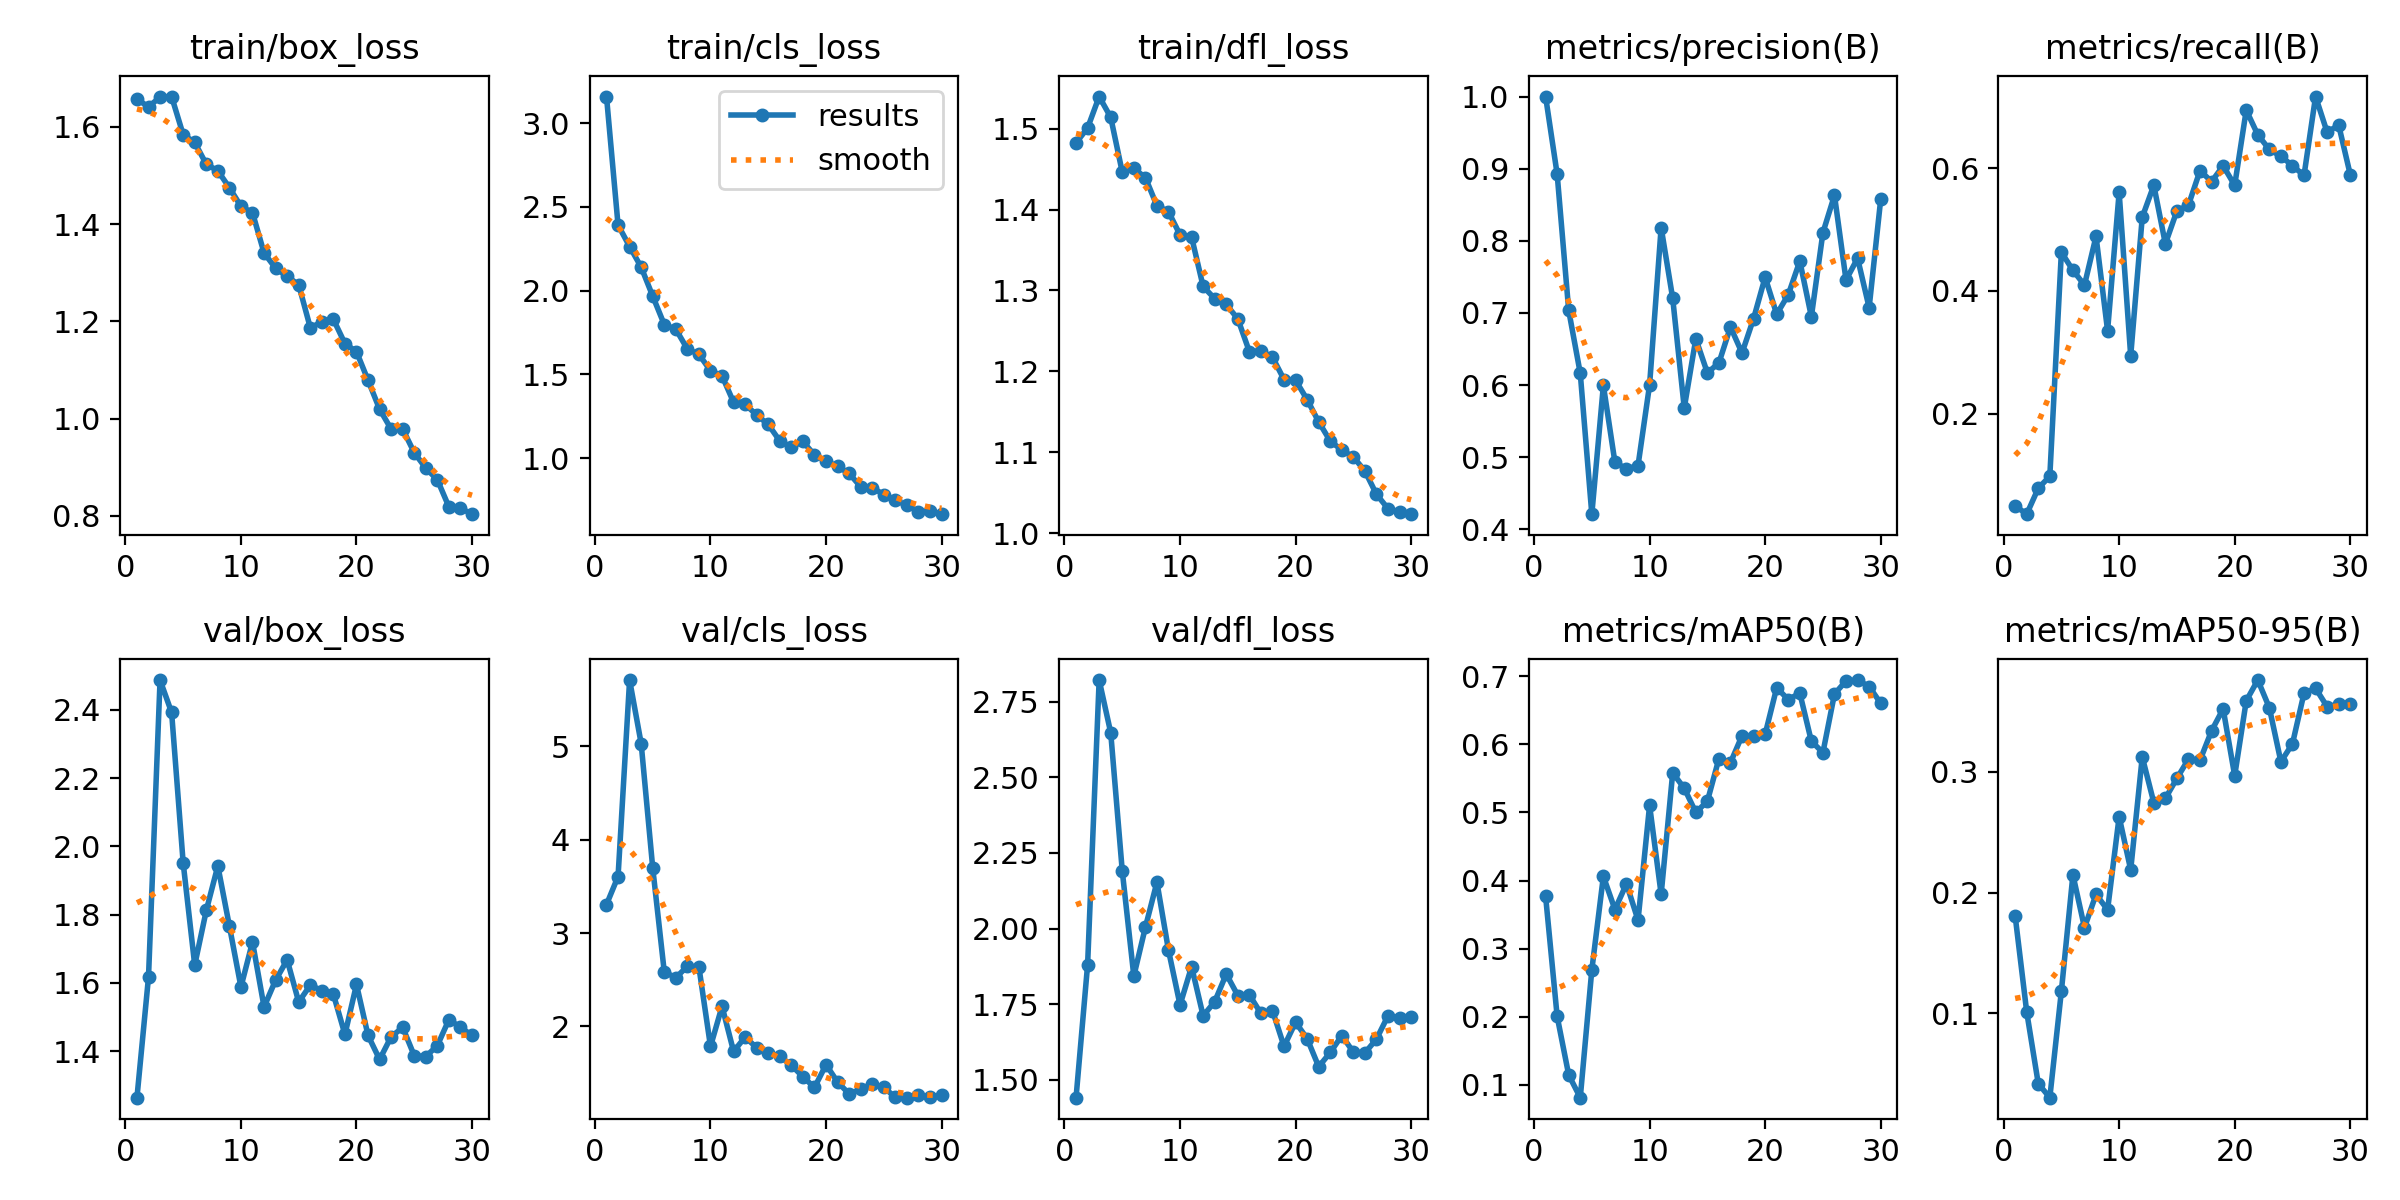

In [14]:
display(Image(filename="runs/detect/train-2/results.png"))

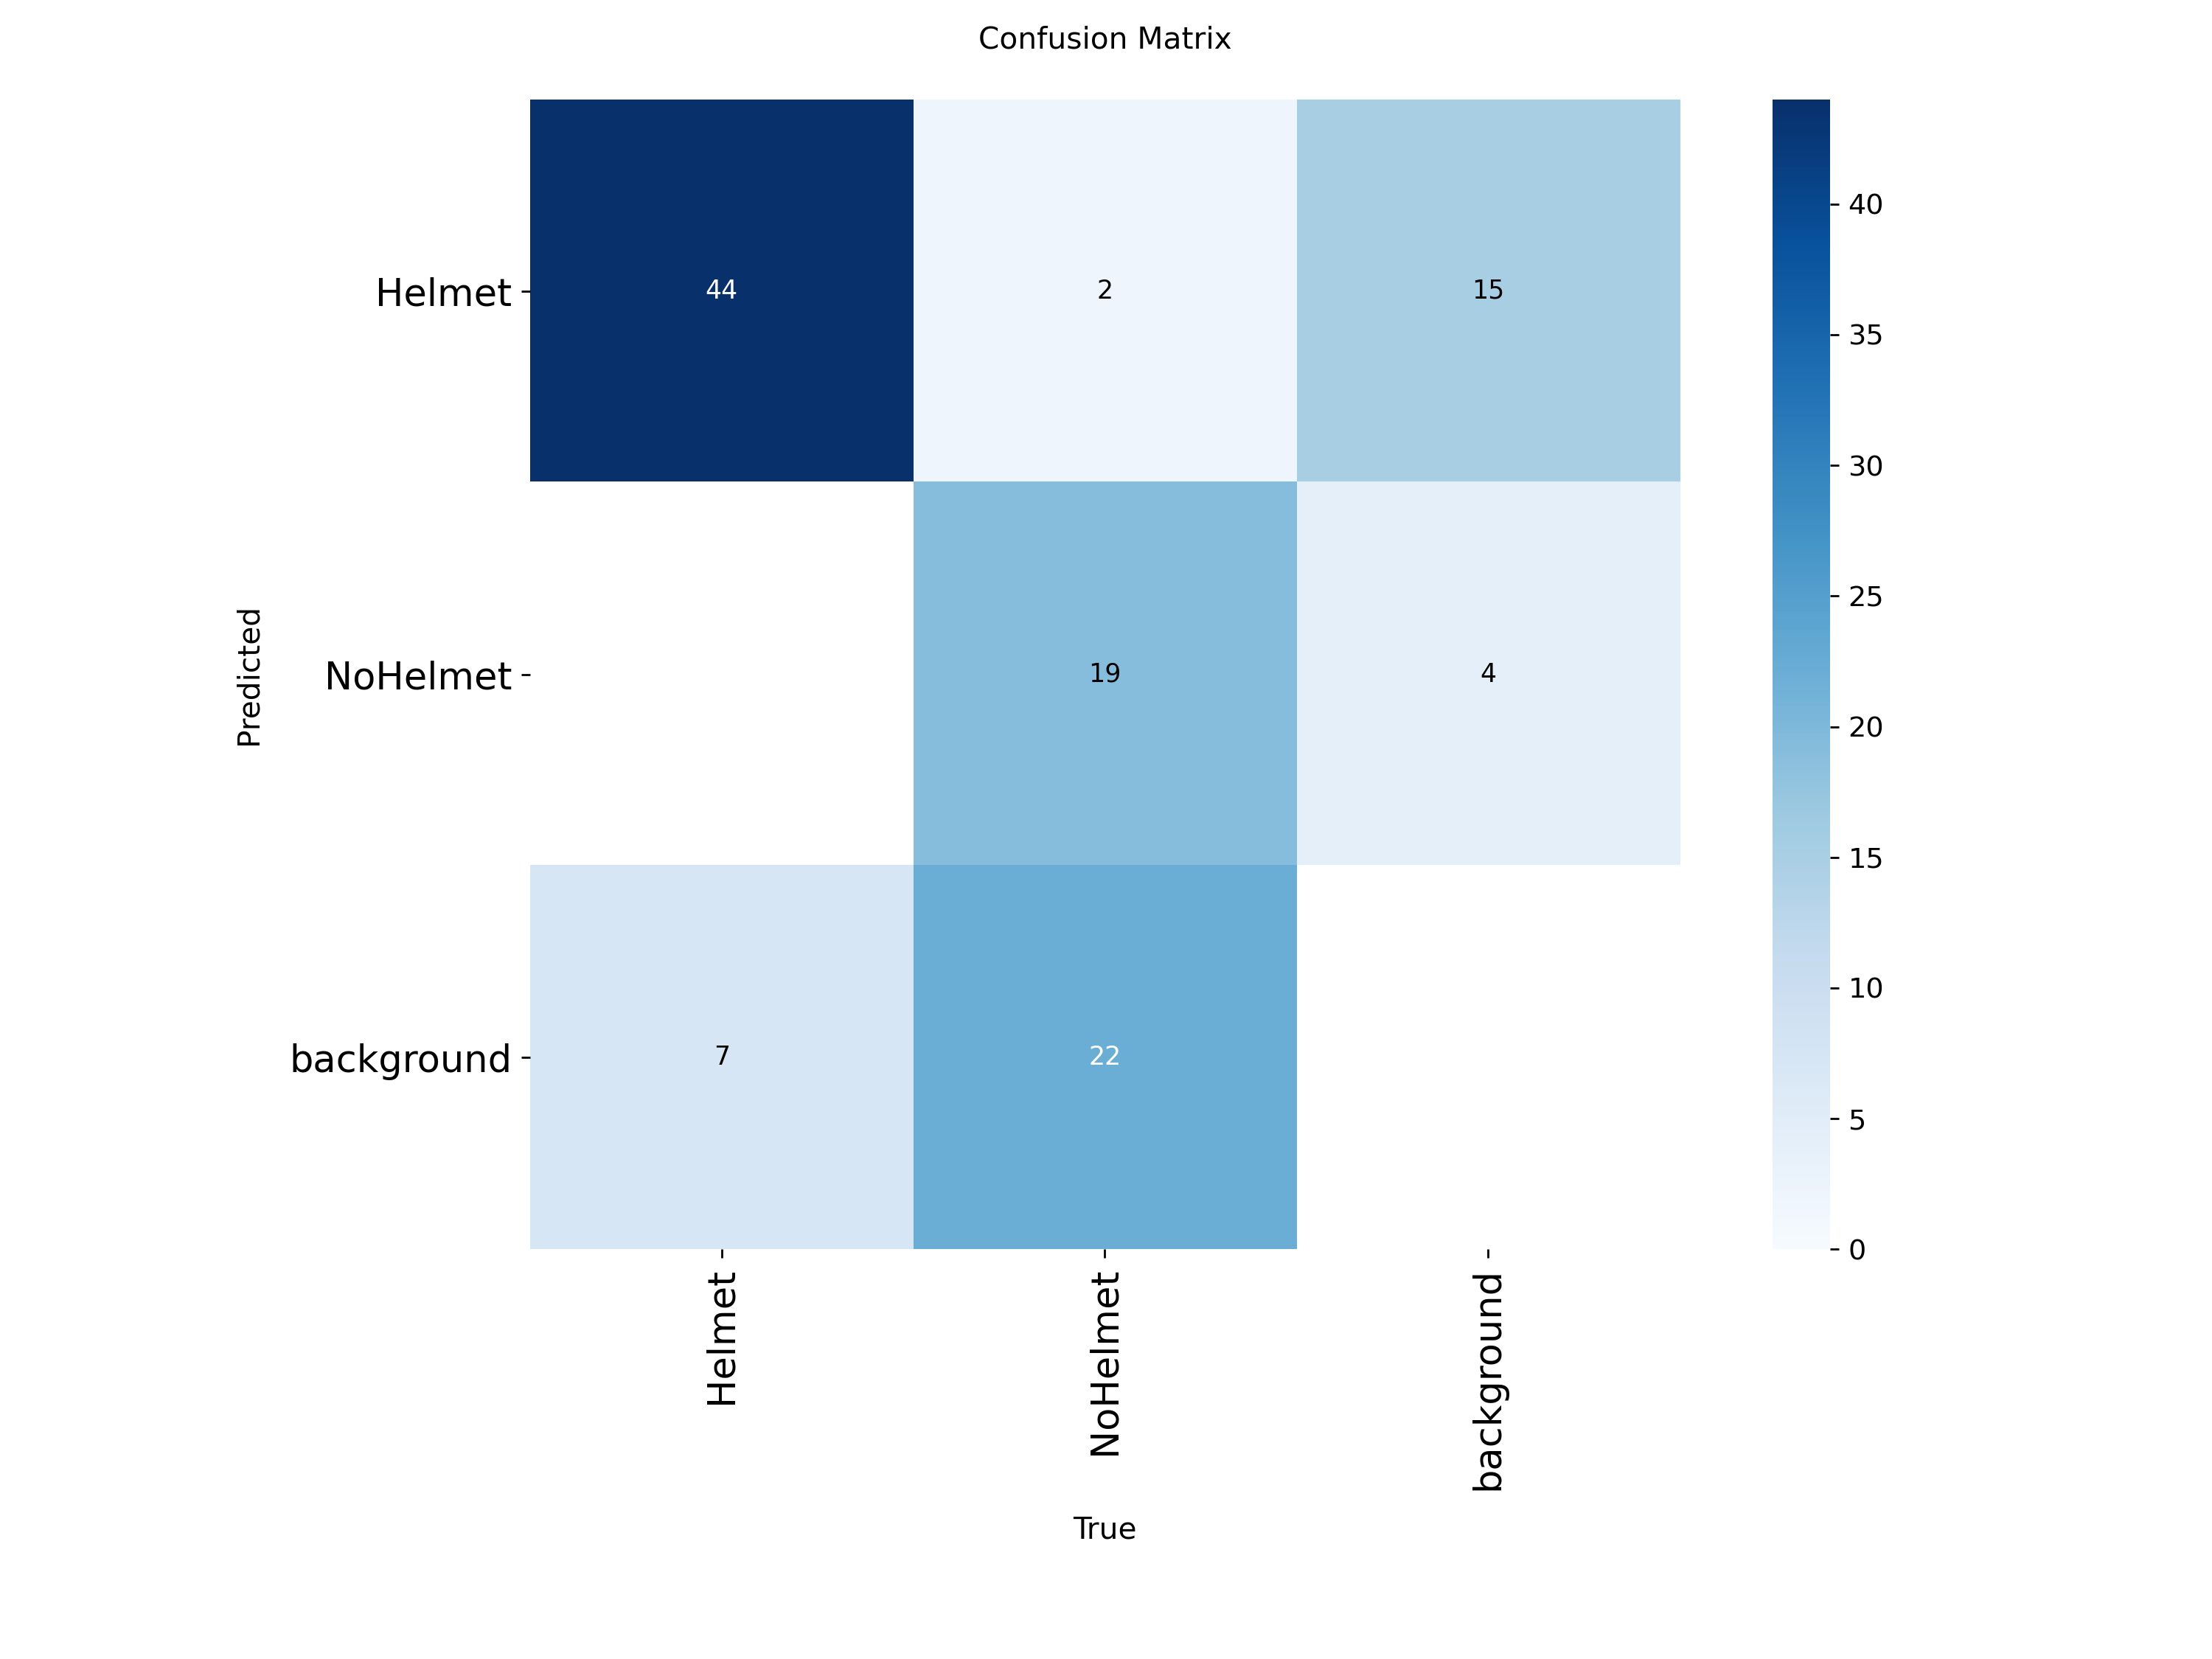

In [16]:
display(Image(filename="runs/detect/train-2/confusion_matrix.png"))

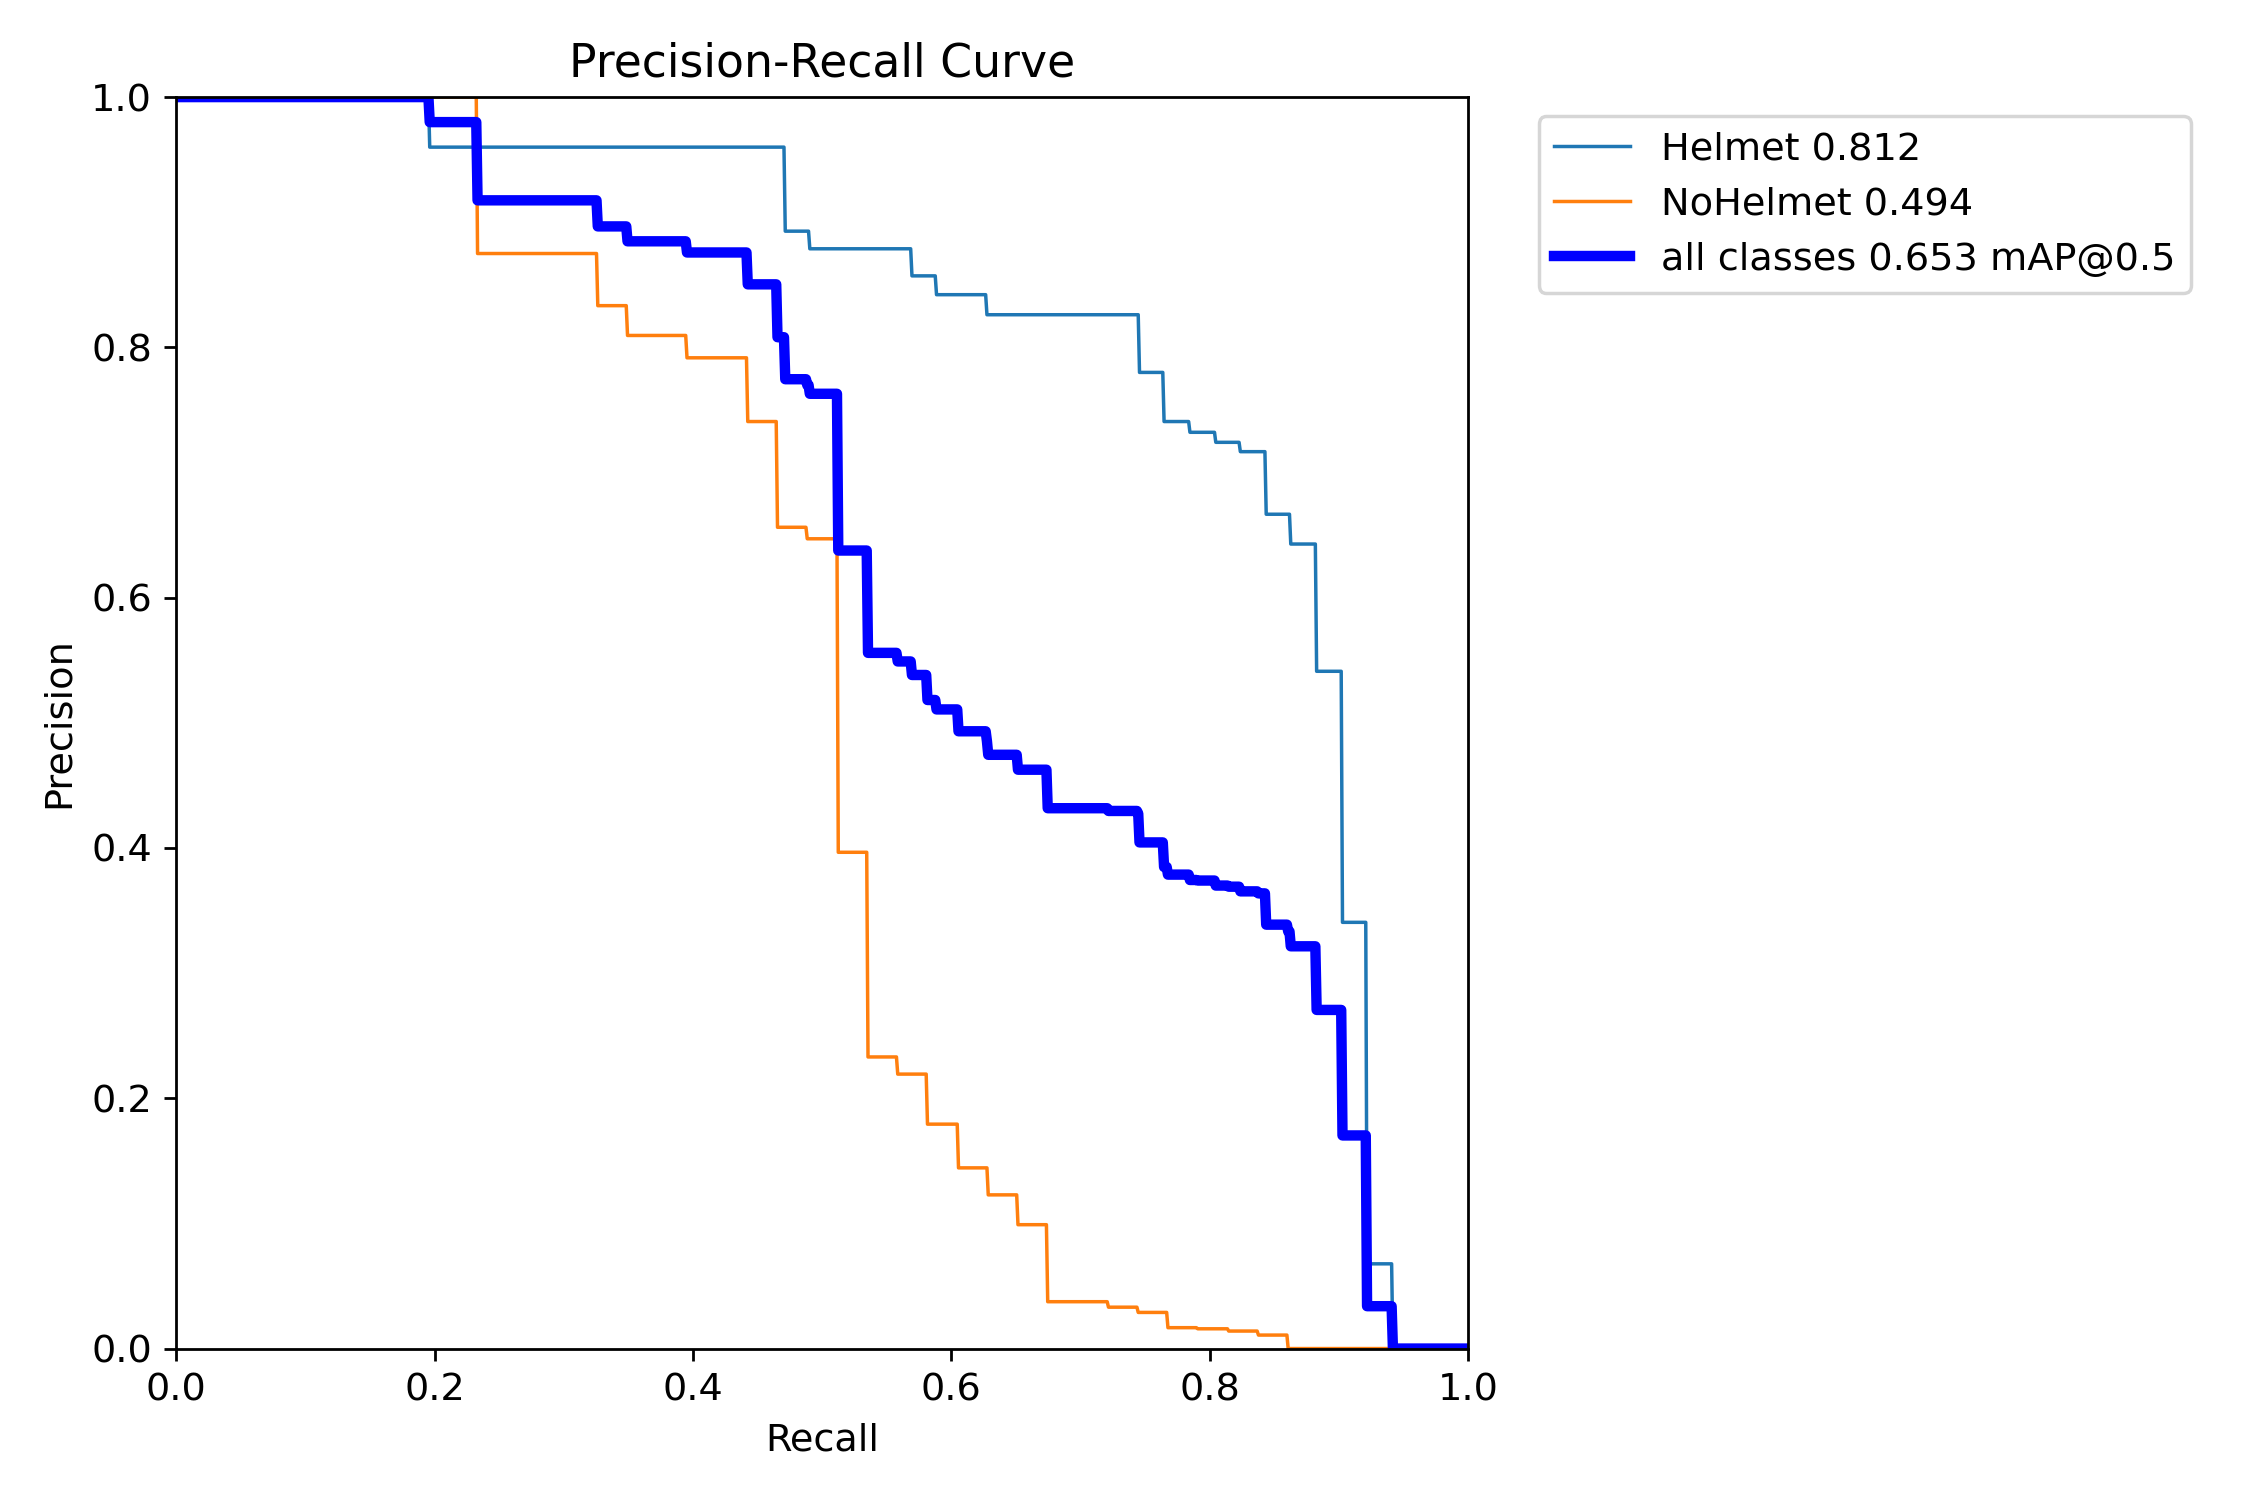

In [23]:
display(Image(filename="runs/detect/train-2/BoxPR_curve.png"))

In [21]:
import os
print(os.listdir('runs/detect/train-2/'))

['confusion_matrix.png', 'results.csv', 'train_batch621.jpg', 'val_batch0_pred.jpg', 'results.png', 'val_batch1_pred.jpg', 'val_batch0_labels.jpg', 'train_batch620.jpg', 'train_batch0.jpg', 'train_batch2.jpg', 'train_batch1.jpg', 'val_batch1_labels.jpg', 'confusion_matrix_normalized.png', 'args.yaml', 'train_batch622.jpg', 'BoxF1_curve.png', 'labels.jpg', 'BoxPR_curve.png', 'BoxR_curve.png', 'BoxP_curve.png', 'weights']


In [24]:
from google.colab import files

files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files

uploaded = files.upload()

Saving Image (6).jpg to Image (6).jpg


In [27]:
model = YOLO("runs/detect/train-2/weights/best.pt")

results = model.predict(
    source="Image (6).jpg",
    conf=0.5,
    save=True
)


image 1/1 /content/Image (6).jpg: 448x640 1 Helmet, 124.6ms
Speed: 1.8ms preprocess, 124.6ms inference, 4.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


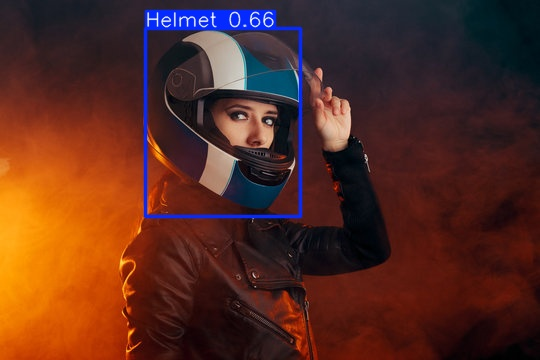

In [28]:
import glob
from IPython.display import Image, display

hasil = glob.glob("runs/detect/predict/*.jpg")

display(Image(filename=hasil[0]))

In [29]:
metrics = model.val()

print(metrics.box.map)
print(metrics.box.map50)
print(metrics.box.map75)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1165.8±402.3 MB/s, size: 52.3 KB)
val: Scanning /content/Helmet-Detection-3/valid/labels.cache... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 10.6Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 59, len(boxes) = 94. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.9s/it 8.8s
                   all         48         94      0.706      0.643      0.653      0.372
                Helmet         36         51      0.662      0.845      0.812      0.565
              NoHelmet         19         43       0.75      0.442      0.494      0.179
Speed: 2.8ms preprocess, 174.1ms inferenc

In [30]:
model.export(format="onnx")

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)

PyTorch: starting from 'runs/detect/train-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 359ms
Prepared 4 packages in 2.02s
Installed 4 packages in 373ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.2s, saved as 'runs/detect/train-2/weights/best.onnx' (11.7 MB)

Export complete (5.5s)
Results saved to /content/runs/detect/train-2/weights/best.onnx
Predict:         yolo predict task=detect model

'runs/detect/train-2/weights/best.onnx'

In [32]:
files.download("runs/detect/train-2/weights/best.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>